# 01. 구급출동현황 EDA (2017~2022)

**대상 파일:** `구급출동현황/구급출동_{연도}.csv` (2017~2022, 각 ~200~240MB)

**핵심 목표:** 구급차 뺑뺑이 현상 파악 — 2·3차 이송 발생률 및 이유 분석

**전략:** 파일이 크므로 연도별 5,000행 샘플링 → 합산 (총 30,000행) 으로 빠르게 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR = Path('../data/구급출동현황')
SAMPLE_N = 5000  # 연도별 샘플 행 수

print('데이터 경로:', DATA_DIR.resolve())
files = sorted(DATA_DIR.glob('구급출동_*.csv'))
print(f'발견된 파일 수: {len(files)}개')
for f in files:
    size_mb = f.stat().st_size / 1024 / 1024
    print(f'  {f.name}: {size_mb:.1f} MB')

데이터 경로: D:\DMU\빅데이터분석프로젝트\BigdataAnalysis-project\data\구급출동현황
발견된 파일 수: 6개
  구급출동_2017.csv: 205.1 MB
  구급출동_2018.csv: 213.7 MB
  구급출동_2019.csv: 206.7 MB
  구급출동_2020.csv: 183.6 MB
  구급출동_2021.csv: 211.2 MB
  구급출동_2022.csv: 236.3 MB


## 1. 구조 파악 — 2022년 파일 샘플 (5행)

In [2]:
df_peek = pd.read_csv(DATA_DIR / '구급출동_2022.csv', nrows=5)
print(f'컬럼 수: {df_peek.shape[1]}')
print('\n컬럼 목록:')
for i, col in enumerate(df_peek.columns):
    print(f'  [{i:2d}] {col}')

컬럼 수: 92

컬럼 목록:
  [ 0] RPTP_NO
  [ 1] REG_CMPTN_SE_NM
  [ 2] PTN_OCRN_TYPE_NM
  [ 3] PTN_SYM_SE_NM
  [ 4] SRIL_ONCR_NM
  [ 5] HRTARST_NM
  [ 6] CRDVSC_CRVSSCR_SE_NM
  [ 7] TRFC_ACDNT_SE_NM
  [ 8] ETC_TRFC_ACDNT_NM
  [ 9] ACDNT_INJR_NM
  [10] ACDNT_ETC_INJR_NM
  [11] ANML_CLSF_NM
  [12] ANML_ETC_CLSF_NM
  [13] NTRMA_DAMG_NM
  [14] NTRMA_ETC_DAMG_NM
  [15] THML_DAMG_NM
  [16] ETC_OCRN_TYPE_NM
  [17] ETC_OCRN_TYPE_DTL_NM
  [18] FRSTN_NM
  [19] CNTR_NM
  [20] LFDAU_NM
  [21] RLF_ACTV_SE_NM
  [22] HLCPT_PMPBLC_EN_NM
  [23] DCLR_YMD
  [24] DCLR_TM
  [25] DCLR_YR
  [26] SEASN_NM
  [27] QTR_NO
  [28] DCLR_MM
  [29] DCLR_DAY
  [30] DCLR_HR
  [31] DCLR_MN
  [32] DCLR_DOW
  [33] DSPT_YMD
  [34] DSPT_TM
  [35] DSPT_YR
  [36] DSPT_MM
  [37] DSPT_DAY
  [38] DSPT_HR
  [39] DSPT_MN
  [40] GRNDS_ARVL_YMD
  [41] GRNDS_ARVL_TM
  [42] GRNDS_ARVL_YR
  [43] GRNDS_ARVL_MM
  [44] GRNDS_ARVL_DAY
  [45] GRNDS_ARVL_HR
  [46] GRNDS_ARVL_MN
  [47] PTN_CNTC_YMD
  [48] PTN_CNTC_TM
  [49] PTN_CNTC_YR
  [50] PTN_CNTC

In [3]:
df_peek.T  # 행/열 전치하여 한눈에 보기

,0,1,2,3,4
RPTP_NO,20221118103M00001,20221103109M00001,20221113103M00001,20221116103M00001,20221116509M00001
REG_CMPTN_SE_NM,등록완료,등록완료,등록완료,등록완료,등록완료
PTN_OCRN_TYPE_NM,질병,질병,질병외,질병외,질병
PTN_SYM_SE_NM,기침,고열,NaN,기타,복통
SRIL_ONCR_NM,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
HR_UNIT_WSPD,1.9,1.9,1.9,1.9,1.9
HR_UNIT_WNDRCT,320,320,320,320,320
HR_UNIT_HUM,41,41,41,41,41
HR_UNIT_SNWFL,NaN,NaN,NaN,NaN,NaN


## 2. 전체 연도 샘플 합산 로드

In [4]:
dfs = []
for f in files:
    year = f.stem.split('_')[-1]
    df_temp = pd.read_csv(f, nrows=SAMPLE_N)
    df_temp['_year'] = int(year)
    dfs.append(df_temp)
    print(f'  {f.name}: {len(df_temp):,}행 로드 완료')

df = pd.concat(dfs, ignore_index=True)
print(f'\n합산 데이터: {df.shape[0]:,}행 × {df.shape[1]}열')

  구급출동_2017.csv: 5,000행 로드 완료
  구급출동_2018.csv: 5,000행 로드 완료
  구급출동_2019.csv: 5,000행 로드 완료


  구급출동_2020.csv: 5,000행 로드 완료


  구급출동_2021.csv: 5,000행 로드 완료
  구급출동_2022.csv: 5,000행 로드 완료

합산 데이터: 30,000행 × 93열


## 3. 기본 EDA

In [5]:
print('데이터 타입:')
print(df.dtypes.value_counts())

데이터 타입:
float64    43
object     36
int64      14
Name: count, dtype: int64


In [6]:
# 결측값 비율 상위 20개
null_rate = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print('결측값 비율 상위 20개 컬럼:')
print(null_rate.head(20).to_string())

결측값 비율 상위 20개 컬럼:
LFDAU_NM            100.000000
DCLR_TM             100.000000
GRNDS_DPTRE_HR      100.000000
PTN_CNTC_MN         100.000000
PTN_CNTC_HR         100.000000
GRNDS_ARVL_HR       100.000000
GRNDS_ARVL_MN       100.000000
GRNDS_ARVL_TM       100.000000
DSPT_MN             100.000000
DSPT_HR             100.000000
DSPT_TM             100.000000
DCLR_MN             100.000000
CBK_MN              100.000000
GRNDS_DPTRE_MN      100.000000
CBK_TM              100.000000
CBK_HR              100.000000
PTN_CNTC_TM         100.000000
GRNDS_DPTRE_TM      100.000000
DCLR_HR             100.000000
ANML_ETC_CLSF_NM     99.996667


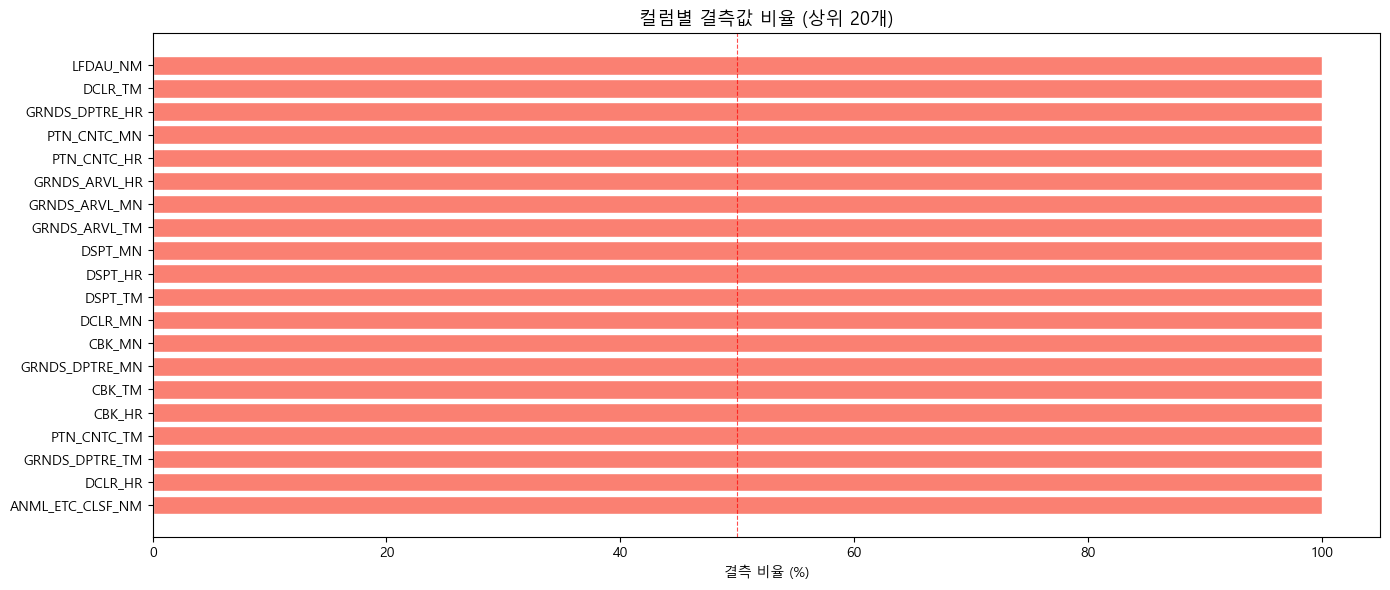

In [7]:
# 결측값 히트맵 (샘플 50행)
fig, ax = plt.subplots(figsize=(14, 6))
null_df = null_rate[null_rate > 0]
ax.barh(null_df.index[:20][::-1], null_df.values[:20][::-1], color='salmon', edgecolor='white')
ax.set_xlabel('결측 비율 (%)')
ax.set_title('컬럼별 결측값 비율 (상위 20개)', fontsize=13)
ax.axvline(50, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.show()

## 4. 연도별 출동 건수 추이

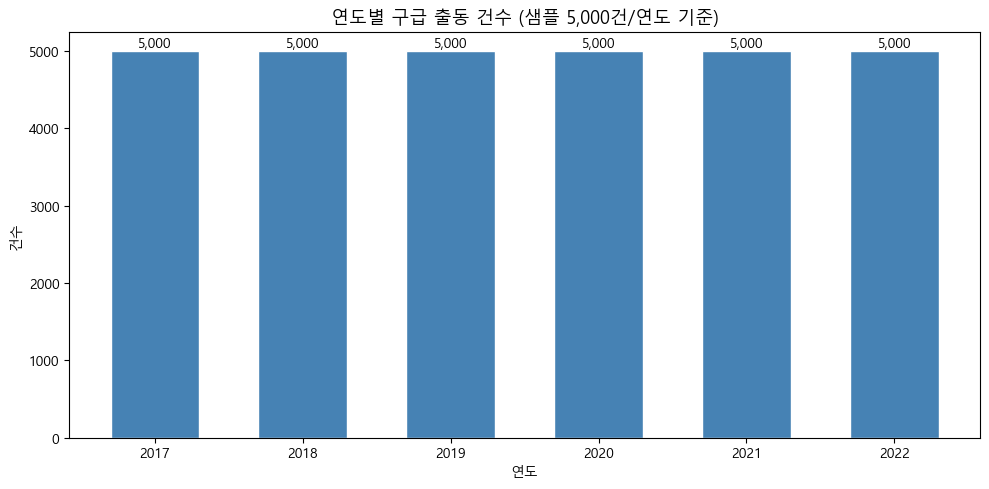

In [8]:
# 샘플 데이터이므로 비율로 표시 (DCLR_YR 컬럼 사용)
year_col = 'DCLR_YR' if 'DCLR_YR' in df.columns else '_year'

yearly = df.groupby(year_col).size()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(yearly.index.astype(str), yearly.values, color='steelblue', edgecolor='white', width=0.6)
ax.set_title(f'연도별 구급 출동 건수 (샘플 {SAMPLE_N:,}건/연도 기준)', fontsize=13)
ax.set_xlabel('연도')
ax.set_ylabel('건수')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 5. 시간대 패턴 분석

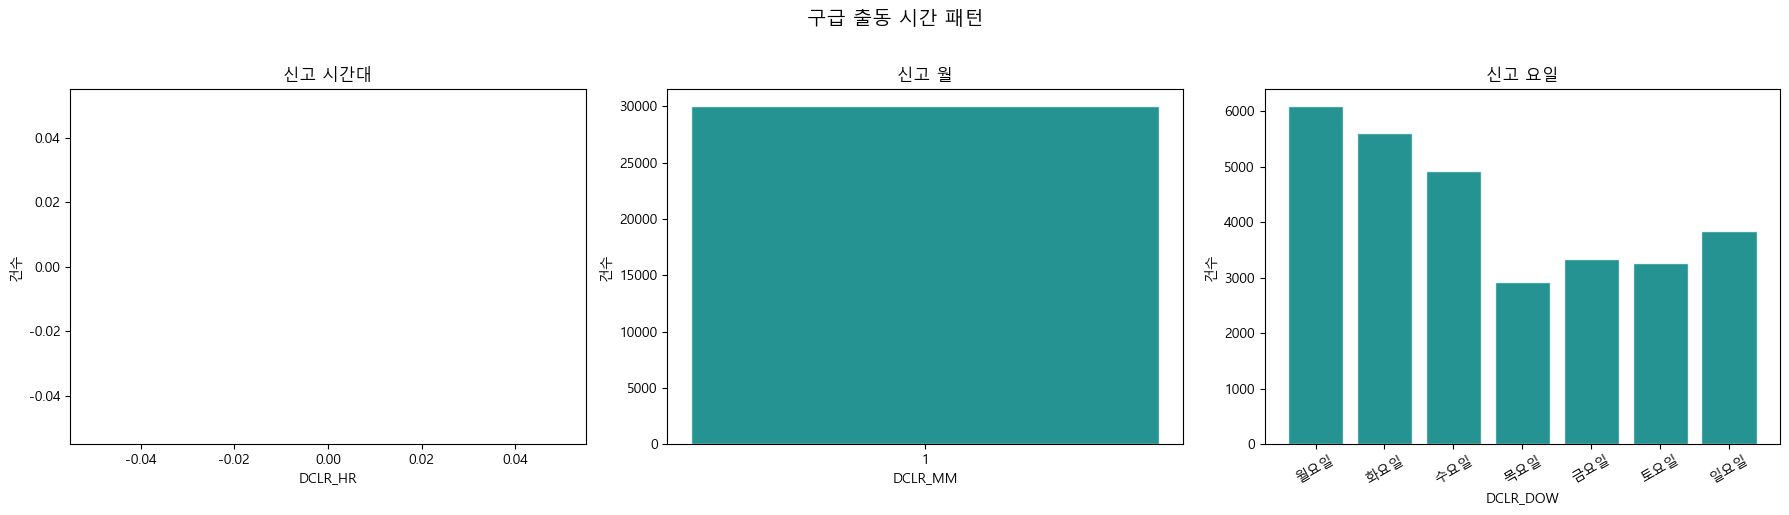

In [9]:
time_cols = {
    'DCLR_HR': '신고 시간대',
    'DCLR_MM': '신고 월',
    'DCLR_DOW': '신고 요일',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, label) in zip(axes, time_cols.items()):
    if col not in df.columns:
        ax.text(0.5, 0.5, f'컬럼 없음: {col}', ha='center', va='center', transform=ax.transAxes)
        continue
    
    counts = df[col].value_counts().sort_index()
    
    if col == 'DCLR_DOW':
        order = ['월요일','화요일','수요일','목요일','금요일','토요일','일요일']
        counts = counts.reindex([o for o in order if o in counts.index])
    
    ax.bar(counts.index.astype(str), counts.values, color='teal', edgecolor='white', alpha=0.85)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('건수')
    if col == 'DCLR_DOW':
        ax.tick_params(axis='x', rotation=30)

plt.suptitle('구급 출동 시간 패턴', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. 환자 특성 분석

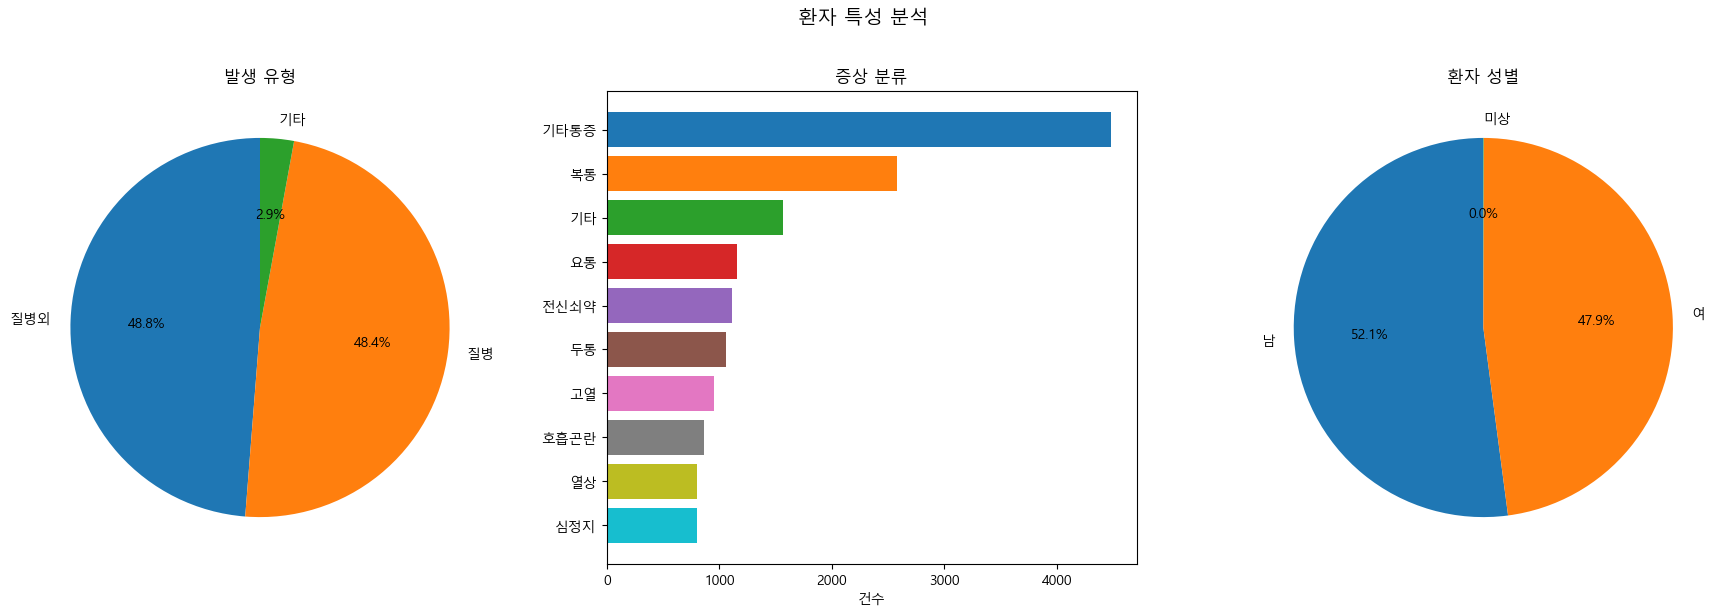

In [10]:
patient_cols = {
    'PTN_OCRN_TYPE_NM': '발생 유형',
    'PTN_SYM_SE_NM': '증상 분류',
    'PTN_GNDR_NM': '환자 성별',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, label) in zip(axes, patient_cols.items()):
    if col not in df.columns:
        ax.text(0.5, 0.5, f'컬럼 없음: {col}', ha='center', va='center', transform=ax.transAxes)
        continue
    
    counts = df[col].value_counts().head(10)
    
    if len(counts) <= 3:
        ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    else:
        colors = plt.cm.tab10(np.linspace(0, 1, len(counts)))
        ax.barh(counts.index[::-1], counts.values[::-1], color=colors[::-1])
        ax.set_xlabel('건수')
    
    ax.set_title(label, fontsize=12)

plt.suptitle('환자 특성 분석', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. 지역별 분포

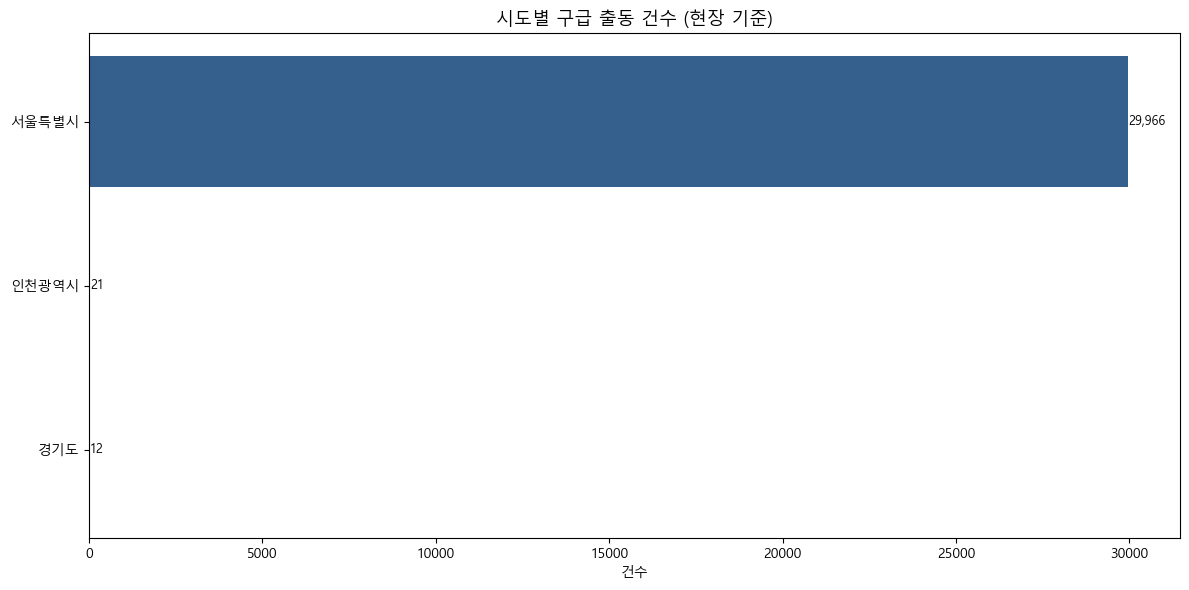

In [11]:
region_col = 'GRNDS_CTPV_NM'  # 현장 시도명

if region_col in df.columns:
    region_counts = df[region_col].value_counts().head(20)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(region_counts)))
    ax.barh(region_counts.index[::-1], region_counts.values[::-1], color=colors[::-1])
    ax.set_title('시도별 구급 출동 건수 (현장 기준)', fontsize=13)
    ax.set_xlabel('건수')
    for i, v in enumerate(region_counts.values[::-1]):
        ax.text(v + 5, i, f'{v:,}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print(f'컬럼 없음: {region_col}')
    print('지역 관련 컬럼:', [c for c in df.columns if 'CTPV' in c or 'SGG' in c])

## 8. 응답시간 분석 (출동→현장도착)

In [12]:
# 시간 컬럼 파싱
def parse_time(ymd_col, tm_col, df):
    try:
        dt = pd.to_datetime(
            df[ymd_col].astype(str) + df[tm_col].astype(str).str.zfill(6),
            format='%Y%m%d%H%M%S',
            errors='coerce'
        )
        return dt
    except Exception as e:
        print(f'파싱 오류 ({ymd_col}, {tm_col}): {e}')
        return pd.NaT

time_pairs = [
    ('DCLR_YMD', 'DCLR_TM', '신고시간'),
    ('DSPT_YMD', 'DSPT_TM', '출동시간'),
    ('GRNDS_ARVL_YMD', 'GRNDS_ARVL_TM', '현장도착'),
    ('PTN_CNTC_YMD', 'PTN_CNTC_TM', '환자접촉'),
    ('GRNDS_DPTRE_YMD', 'GRNDS_DPTRE_TM', '현장출발'),
    ('CBK_YMD', 'CBK_TM', '복귀'),
]

df_time = df.copy()
for ymd, tm, label in time_pairs:
    if ymd in df.columns and tm in df.columns:
        df_time[label] = parse_time(ymd, tm, df)
        valid = df_time[label].notna().sum()
        print(f'{label}: {valid:,}건 파싱 성공')

신고시간: 0건 파싱 성공
출동시간: 0건 파싱 성공
현장도착: 0건 파싱 성공
환자접촉: 0건 파싱 성공
현장출발: 0건 파싱 성공
복귀: 0건 파싱 성공


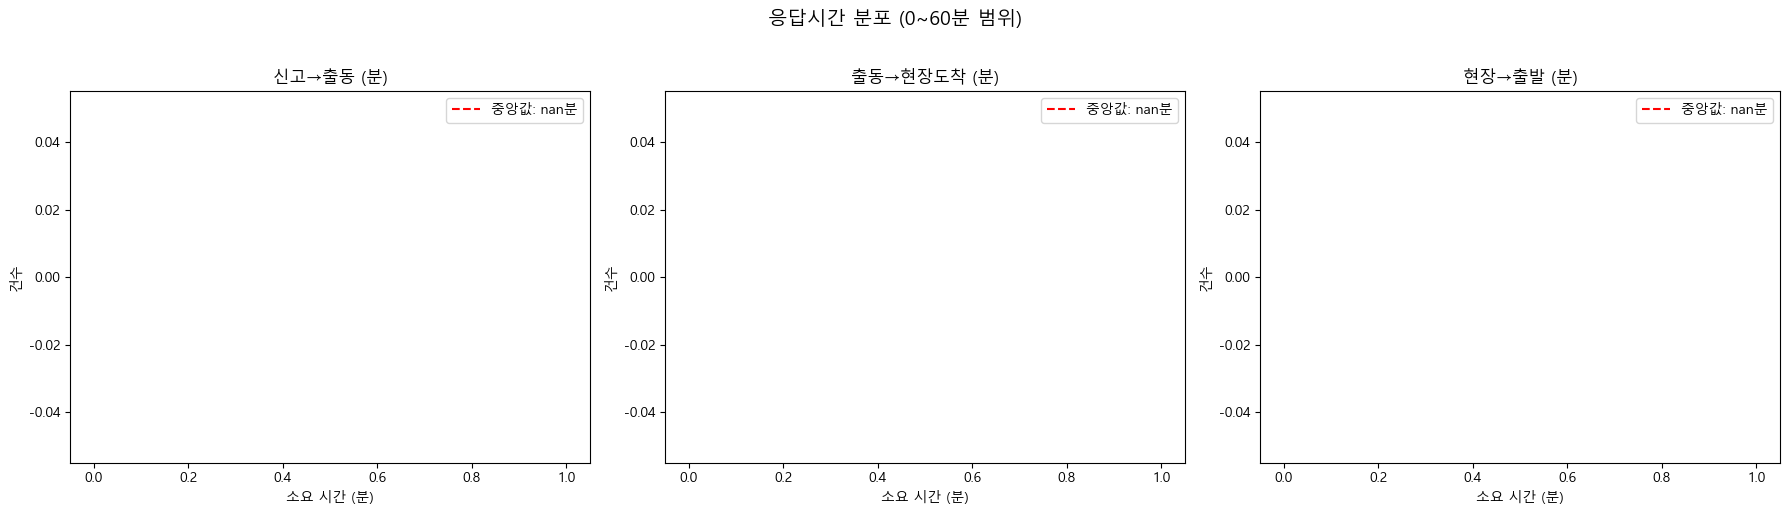

In [13]:
# 응답시간 계산 (분 단위)
response_times = {}

if '신고시간' in df_time.columns and '출동시간' in df_time.columns:
    response_times['신고→출동 (분)'] = (df_time['출동시간'] - df_time['신고시간']).dt.total_seconds() / 60

if '출동시간' in df_time.columns and '현장도착' in df_time.columns:
    response_times['출동→현장도착 (분)'] = (df_time['현장도착'] - df_time['출동시간']).dt.total_seconds() / 60

if '현장도착' in df_time.columns and '현장출발' in df_time.columns:
    response_times['현장→출발 (분)'] = (df_time['현장출발'] - df_time['현장도착']).dt.total_seconds() / 60

if response_times:
    n_plots = len(response_times)
    fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    
    for ax, (label, times) in zip(axes, response_times.items()):
        clean = times[(times >= 0) & (times <= 60)].dropna()
        ax.hist(clean, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
        ax.axvline(clean.median(), color='red', linestyle='--', label=f'중앙값: {clean.median():.1f}분')
        ax.set_title(label, fontsize=12)
        ax.set_xlabel('소요 시간 (분)')
        ax.set_ylabel('건수')
        ax.legend(fontsize=10)
    
    plt.suptitle('응답시간 분포 (0~60분 범위)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('응답시간 계산에 필요한 시간 컬럼 파싱 실패')

## 9. 핵심 분석 — 구급차 뺑뺑이 (2·3차 이송)

In [14]:
# 이송 관련 컬럼 확인
trans_cols = [c for c in df.columns if 'TRANS' in c or 'GRNDS2' in c or 'GRNDS3' in c]
print('이송 관련 컬럼:')
for col in trans_cols:
    print(f'  {col}')

이송 관련 컬럼:
  GRNDS2_DSTNC
  TRANS2_RSN
  GRNDS3_DSTNC
  TRANS3_RSN
  TRANS_CLSF_NM
  TRANS_CLSF_RSN


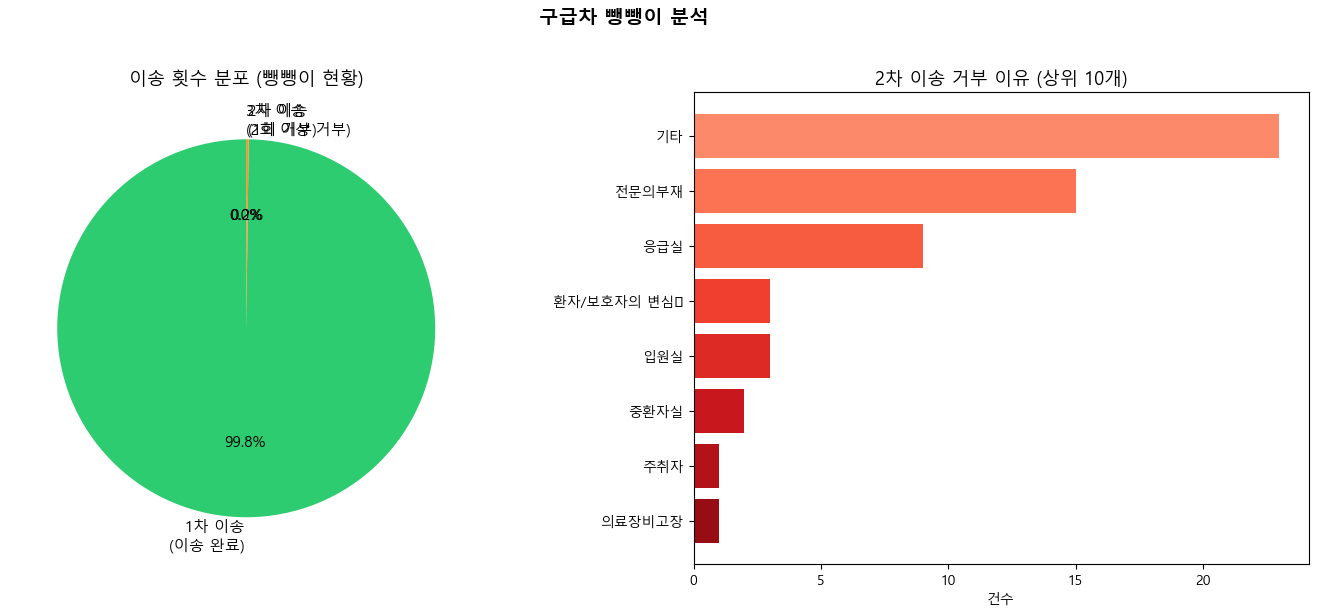


2차 이송 발생: 57건 (0.2%)
3차 이송 발생: 10건 (0.0%)


In [15]:
# 2차 이송 발생 여부
if 'TRANS2_RSN' in df.columns:
    has_trans2 = df['TRANS2_RSN'].notna() & (df['TRANS2_RSN'].astype(str).str.strip() != '')
    has_trans3 = df['TRANS3_RSN'].notna() & (df['TRANS3_RSN'].astype(str).str.strip() != '') if 'TRANS3_RSN' in df.columns else pd.Series([False]*len(df))
    
    labels = ['1차 이송\n(이송 완료)', '2차 이송\n(1회 거부)', '3차 이송\n(2회 이상 거부)']
    sizes = [
        (~has_trans2).sum(),
        (has_trans2 & ~has_trans3).sum(),
        has_trans3.sum()
    ]
    colors_pie = ['#2ecc71', '#f39c12', '#e74c3c']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 파이 차트
    wedges, texts, autotexts = axes[0].pie(
        sizes, labels=labels, autopct='%1.1f%%',
        colors=colors_pie, startangle=90,
        textprops={'fontsize': 11}
    )
    axes[0].set_title('이송 횟수 분포 (뺑뺑이 현황)', fontsize=13)
    
    # 2차 이송 이유
    if has_trans2.sum() > 0:
        trans2_reasons = df.loc[has_trans2, 'TRANS2_RSN'].value_counts().head(10)
        colors_bar = plt.cm.Reds(np.linspace(0.4, 0.9, len(trans2_reasons)))
        axes[1].barh(trans2_reasons.index[::-1], trans2_reasons.values[::-1], color=colors_bar[::-1])
        axes[1].set_title('2차 이송 거부 이유 (상위 10개)', fontsize=13)
        axes[1].set_xlabel('건수')
    
    plt.suptitle('구급차 뺑뺑이 분석', fontsize=14, y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f'\n2차 이송 발생: {has_trans2.sum():,}건 ({has_trans2.mean()*100:.1f}%)')
    print(f'3차 이송 발생: {has_trans3.sum():,}건 ({has_trans3.mean()*100:.1f}%)')
else:
    print('TRANS2_RSN 컬럼이 없습니다. 이송 관련 컬럼:', trans_cols)

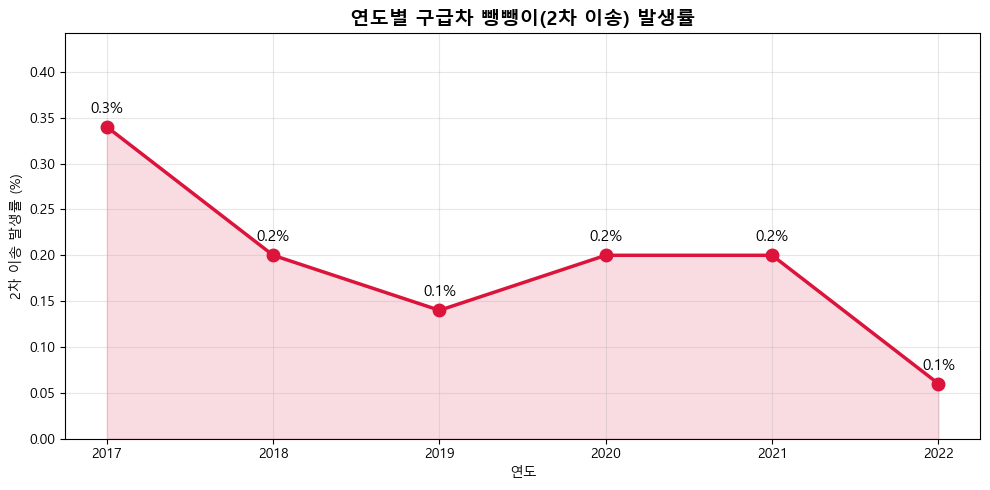

In [16]:
# 연도별 뺑뺑이 발생률 추이
if 'TRANS2_RSN' in df.columns:
    df['has_trans2'] = df['TRANS2_RSN'].notna() & (df['TRANS2_RSN'].astype(str).str.strip() != '')
    
    yearly_rate = df.groupby(year_col)['has_trans2'].agg(['sum', 'count'])
    yearly_rate['rate'] = yearly_rate['sum'] / yearly_rate['count'] * 100
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(yearly_rate.index.astype(str), yearly_rate['rate'],
            marker='o', linewidth=2.5, markersize=9, color='crimson')
    ax.fill_between(yearly_rate.index.astype(str), yearly_rate['rate'], alpha=0.15, color='crimson')
    
    for x, y in zip(yearly_rate.index.astype(str), yearly_rate['rate']):
        ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=11)
    
    ax.set_title('연도별 구급차 뺑뺑이(2차 이송) 발생률', fontsize=14, fontweight='bold')
    ax.set_xlabel('연도')
    ax.set_ylabel('2차 이송 발생률 (%)')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, yearly_rate['rate'].max() * 1.3)
    plt.tight_layout()
    plt.show()

## 10. 이송 분류 및 이송 거리

처리 분류 현황:
TRMN_SE_NM
정상    27603
기타     1226
취소     1038
오인      126
거짓        7
Name: count, dtype: int64


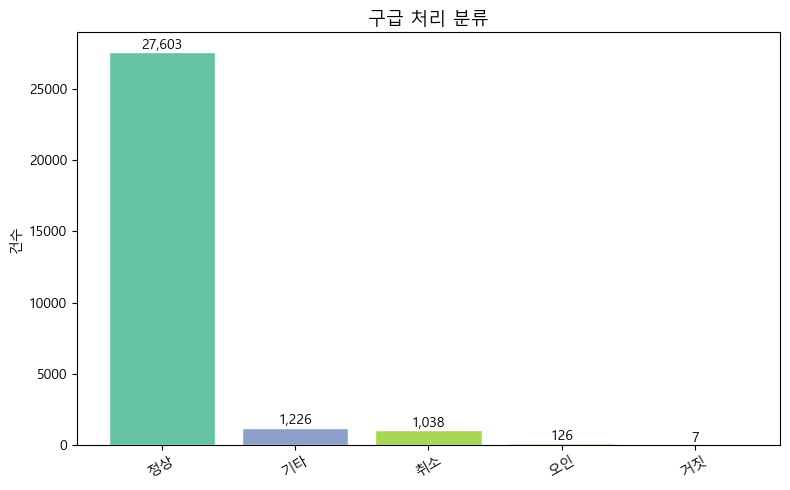

In [17]:
# TRMN_SE_NM: 처리 분류 (이송/미이송/현장사망 등)
if 'TRMN_SE_NM' in df.columns:
    trmn = df['TRMN_SE_NM'].value_counts()
    print('처리 분류 현황:')
    print(trmn)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(trmn)))
    ax.bar(trmn.index, trmn.values, color=colors, edgecolor='white')
    ax.set_title('구급 처리 분류', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('건수')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 5,
                f'{int(p.get_height()):,}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

거리 컬럼: ['GRNDS_DSTNC', 'GRNDS2_DSTNC', 'GRNDS3_DSTNC']


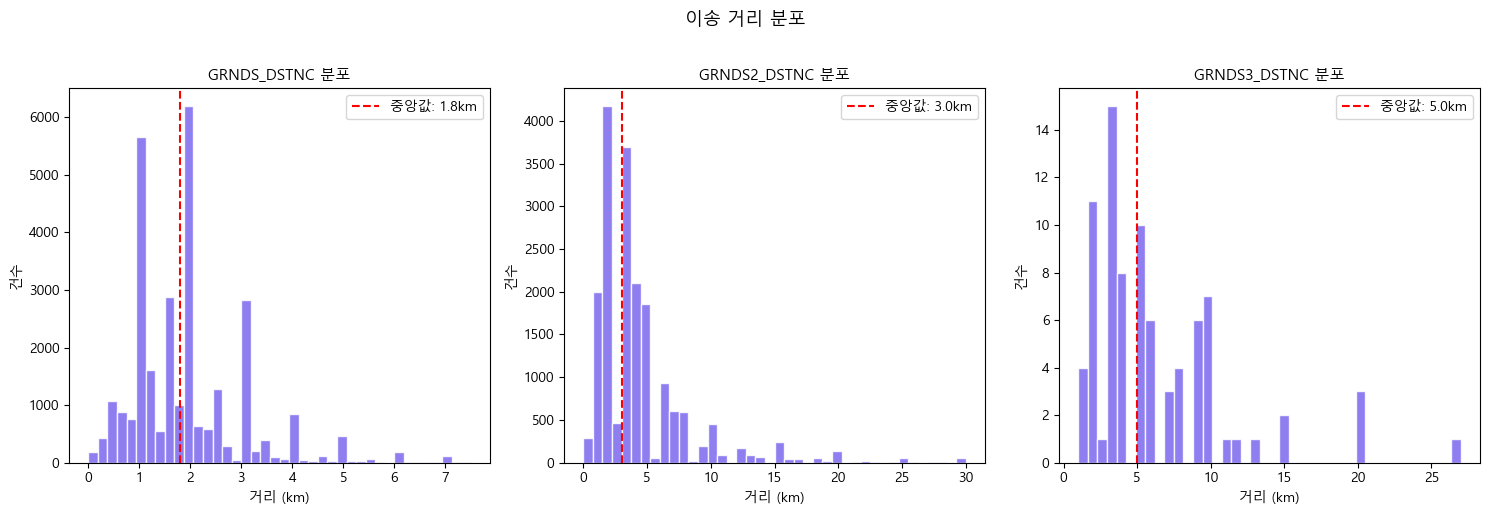

In [18]:
# 이송 거리 분포
dist_cols = [c for c in df.columns if 'DSTNC' in c]
print('거리 컬럼:', dist_cols)

if dist_cols:
    fig, axes = plt.subplots(1, len(dist_cols), figsize=(5*len(dist_cols), 5))
    if len(dist_cols) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, dist_cols):
        data = pd.to_numeric(df[col], errors='coerce').dropna()
        data = data[(data >= 0) & (data <= data.quantile(0.99))]
        ax.hist(data, bins=40, color='mediumslateblue', edgecolor='white', alpha=0.85)
        ax.axvline(data.median(), color='red', linestyle='--', label=f'중앙값: {data.median():.1f}km')
        ax.set_title(f'{col} 분포', fontsize=11)
        ax.set_xlabel('거리 (km)')
        ax.set_ylabel('건수')
        ax.legend()
    
    plt.suptitle('이송 거리 분포', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## 11. 날씨와 출동 상관

날씨 컬럼: ['HR_UNIT_ARTMP', 'HR_UNIT_RN', 'HR_UNIT_WSPD', 'HR_UNIT_WNDRCT', 'HR_UNIT_HUM', 'HR_UNIT_SNWFL', 'HR_UNIT_VSDST']


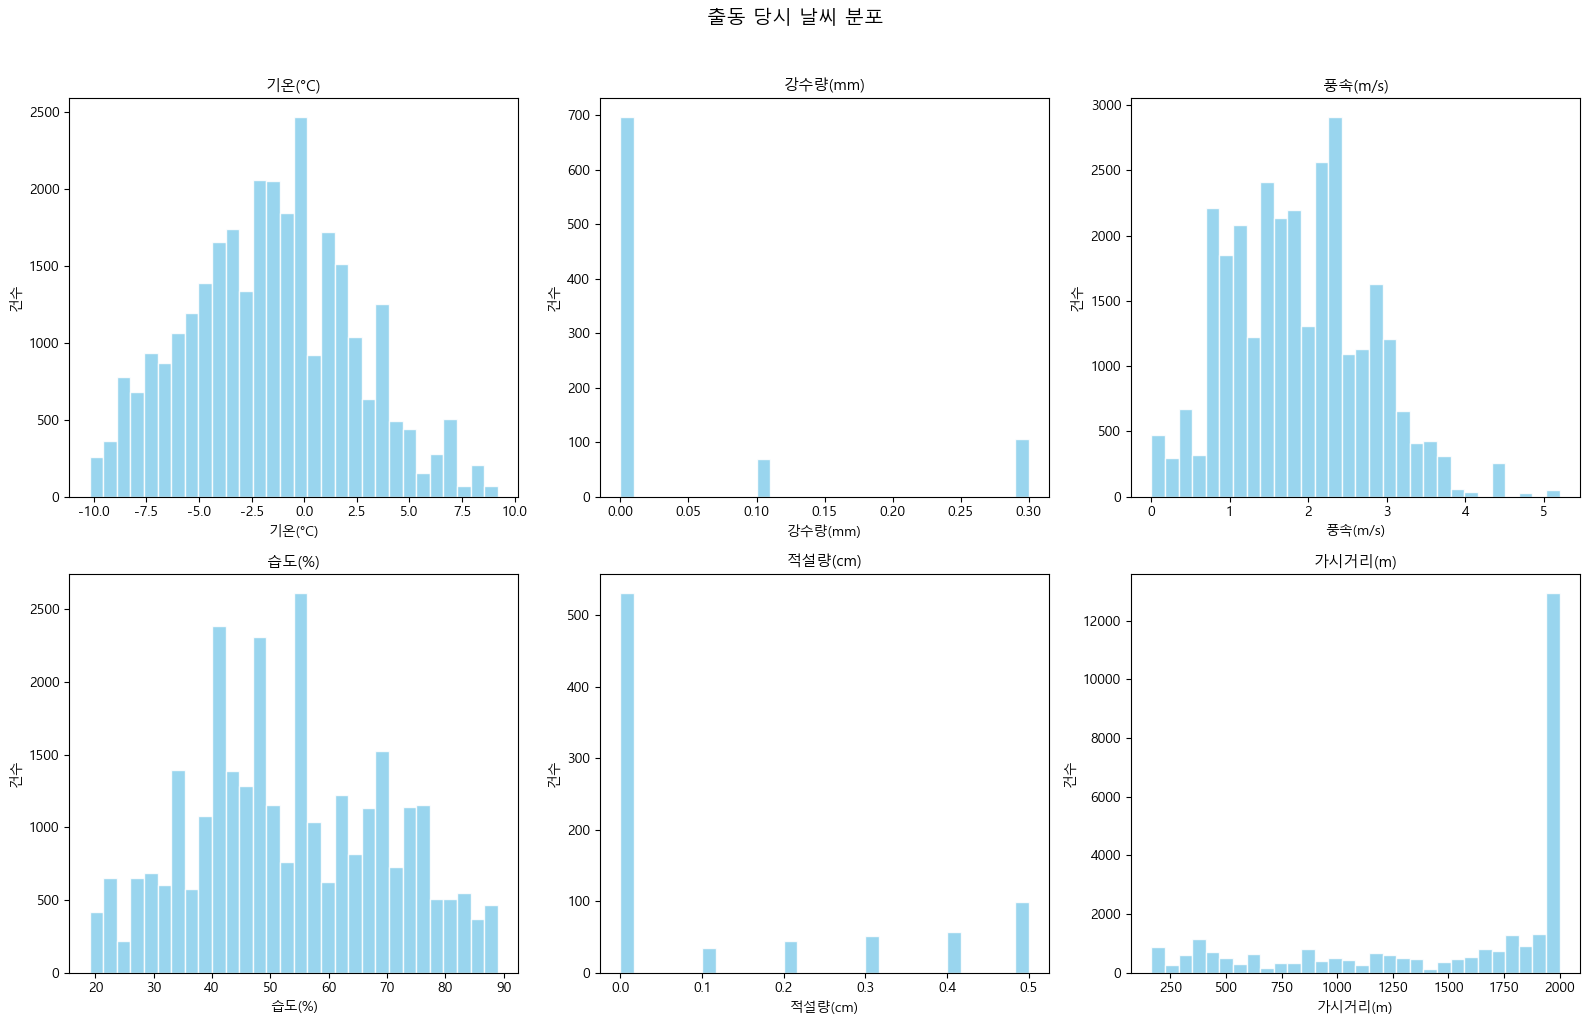

In [19]:
weather_cols = [c for c in df.columns if 'HR_UNIT' in c]
print('날씨 컬럼:', weather_cols)

weather_labels = {
    'HR_UNIT_ARTMP': '기온(°C)',
    'HR_UNIT_RN': '강수량(mm)',
    'HR_UNIT_WSPD': '풍속(m/s)',
    'HR_UNIT_HUM': '습도(%)',
    'HR_UNIT_SNWFL': '적설량(cm)',
    'HR_UNIT_VSDST': '가시거리(m)',
}

available_weather = [c for c in weather_labels if c in df.columns]

if available_weather:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(available_weather[:6]):
        ax = axes[i]
        data = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(data) > 0:
            ax.hist(data, bins=30, color='skyblue', edgecolor='white', alpha=0.85)
            ax.set_title(weather_labels.get(col, col), fontsize=11)
            ax.set_xlabel(weather_labels.get(col, col))
            ax.set_ylabel('건수')
        else:
            ax.text(0.5, 0.5, '데이터 없음', ha='center', va='center', transform=ax.transAxes)
    
    for j in range(len(available_weather), 6):
        axes[j].set_visible(False)
    
    plt.suptitle('출동 당시 날씨 분포', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 12. 요약 통계

In [20]:
print('=== 구급출동현황 EDA 요약 ===')
print(f'  분석 대상: 2017~2022년, 연도별 {SAMPLE_N:,}건 샘플')
print(f'  총 샘플 수: {len(df):,}건')
print(f'  컬럼 수: {df.shape[1]}개')

if 'GRNDS_CTPV_NM' in df.columns:
    top_region = df['GRNDS_CTPV_NM'].value_counts().index[0]
    print(f'  가장 많은 출동 지역: {top_region}')

if 'PTN_OCRN_TYPE_NM' in df.columns:
    top_type = df['PTN_OCRN_TYPE_NM'].value_counts().index[0]
    print(f'  가장 많은 발생 유형: {top_type}')

if 'has_trans2' in df.columns:
    print(f'  전체 2차 이송 발생률: {df["has_trans2"].mean()*100:.2f}%')

=== 구급출동현황 EDA 요약 ===
  분석 대상: 2017~2022년, 연도별 5,000건 샘플
  총 샘플 수: 30,000건
  컬럼 수: 94개
  가장 많은 출동 지역: 서울특별시
  가장 많은 발생 유형: 질병외
  전체 2차 이송 발생률: 0.19%
